## Covariance Based Dynamic Risk Parity Portfolio with Volatility Targeting
### _Written by Matteo Cunsolo_

In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from pathlib import Path
import seaborn as sns

#### Let's import all the csvs, check the data and merge it in a single dataframe
##### Taking only the Closing Prices and making it a Pandas Series

In [2]:
#Bonds
path_bonds=Path("CSV_Files/Bonds")
print("______________________")
print("LOADING BONDS...")

for file in path_bonds.glob("*.csv"):
    name=file.stem
    globals()[name]=pd.read_csv(file,header=0, index_col=0, parse_dates=True,
                    na_values=-99.99)
    print(name,"--- Loaded")
#commodities

path_comm=Path("CSV_Files/Commodities")
print("______________________")
print("LOADING COMMODITIES...")

for file in path_comm.glob("*.csv"):
    name=file.stem
    globals()[name] = pd.read_csv(file,header=0, index_col=0, parse_dates=True,
                    na_values=-99.99)["Close"].rename(name)
    print(name,"--- Loaded")
    
print("______________________")
      
#Stocks

path_stocks=Path("CSV_Files/Stocks")
print("LOADING STOCKS...")

for file in path_stocks.glob("*csv"):
    name=file.stem
    globals()[name]=pd.read_csv(file,header=0, index_col=0, parse_dates=True,
                    na_values=-99.99)["Close"].rename(name)
    print(name,"--- Loaded")
print("______________________")

______________________
LOADING BONDS...
Three_Month_US_Treasury_Bill --- Loaded
______________________
LOADING COMMODITIES...
copper --- Loaded
gold --- Loaded
oil --- Loaded
______________________
LOADING STOCKS...
AIG --- Loaded
ATandT --- Loaded
bankofamerica --- Loaded
boeing --- Loaded
citigroup --- Loaded
cocacola --- Loaded
dupont --- Loaded
dupont_out --- Loaded
exxon --- Loaded
fedex --- Loaded
ford --- Loaded
generalelectric --- Loaded
ibm --- Loaded
mcdonalds --- Loaded
merck --- Loaded
proctergamble --- Loaded
southerncompany --- Loaded
walmart --- Loaded
______________________


In [3]:
#putting them all togheter into a dataframe
prices=pd.concat([AIG,ATandT,bankofamerica,boeing,citigroup,cocacola,dupont,exxon,fedex,ford,generalelectric,
                  ibm,mcdonalds,merck,proctergamble,southerncompany,walmart,gold,oil,copper], axis=1)

#we are going to forward fill dates with maximum 1 day NaN and then drop furthers NaNs to align on common dates
prices= prices.ffill(limit=1).dropna()

In [4]:
prices

,AIG,ATandT,bankofamerica,boeing,citigroup,cocacola,dupont,exxon,fedex,ford,generalelectric,ibm,mcdonalds,merck,proctergamble,southerncompany,walmart,gold,oil,copper
1990-01-02,137.238,2.60664,6.21935,16.065,19.7758,3.36448,5.76454,7.44833,10.6439,2.81088,26.7472,16.0393,6.19224,6.49590,6.17343,2.41310,1.40362,402.100,22.88,1.0900
1990-01-03,137.070,2.56156,6.26973,16.460,20.0246,3.31613,5.86859,7.37441,10.7806,2.82273,26.6985,16.1808,6.12752,6.59714,6.15932,2.42495,1.40362,396.400,23.81,1.0900
1990-01-04,135.113,2.53001,6.13519,16.395,19.7758,3.29890,5.77235,7.30002,10.6980,2.82273,26.5503,16.3681,6.01333,6.49590,6.03965,2.31863,1.39603,400.800,23.41,1.1175
1990-01-05,131.085,2.40838,6.00076,16.162,19.9443,3.27130,5.74386,7.26336,10.4237,2.78729,26.3077,16.3203,5.90613,6.36325,5.93389,2.27731,1.38086,408.500,23.07,1.1300
1990-01-08,130.278,2.44900,6.03414,16.365,20.1087,3.34363,5.71463,7.37441,10.4483,2.78729,26.4565,16.4248,6.01333,6.44526,6.03965,2.34195,1.39854,405.000,21.64,1.1400
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-02-24,79.840,28.35000,50.41000,233.390,109.5600,80.72000,51.07000,149.26000,386.5600,14.20000,345.6400,229.3200,333.05000,123.93000,165.28000,95.81000,126.75000,5143.935,65.62,5.9190
2026-02-25,80.150,27.87000,51.69000,230.360,114.3400,80.47000,50.74000,149.06000,382.5900,14.43000,342.8900,237.5400,333.01000,122.46000,163.39000,95.92000,125.75000,5165.025,65.30,5.9845
2026-02-26,80.350,27.46000,52.30000,229.410,116.1900,80.50000,50.35000,148.54000,387.6800,14.41000,340.8400,242.0100,334.53000,119.30000,163.75000,96.35000,124.42000,5185.255,65.10,5.9700
2026-02-27,80.490,28.01000,49.83000,227.530,110.1900,81.56000,50.04000,152.50000,387.0000,14.09000,342.2600,240.2100,341.06000,123.82000,167.20000,97.38000,127.95000,5263.825,66.96,5.9815


<Axes: >

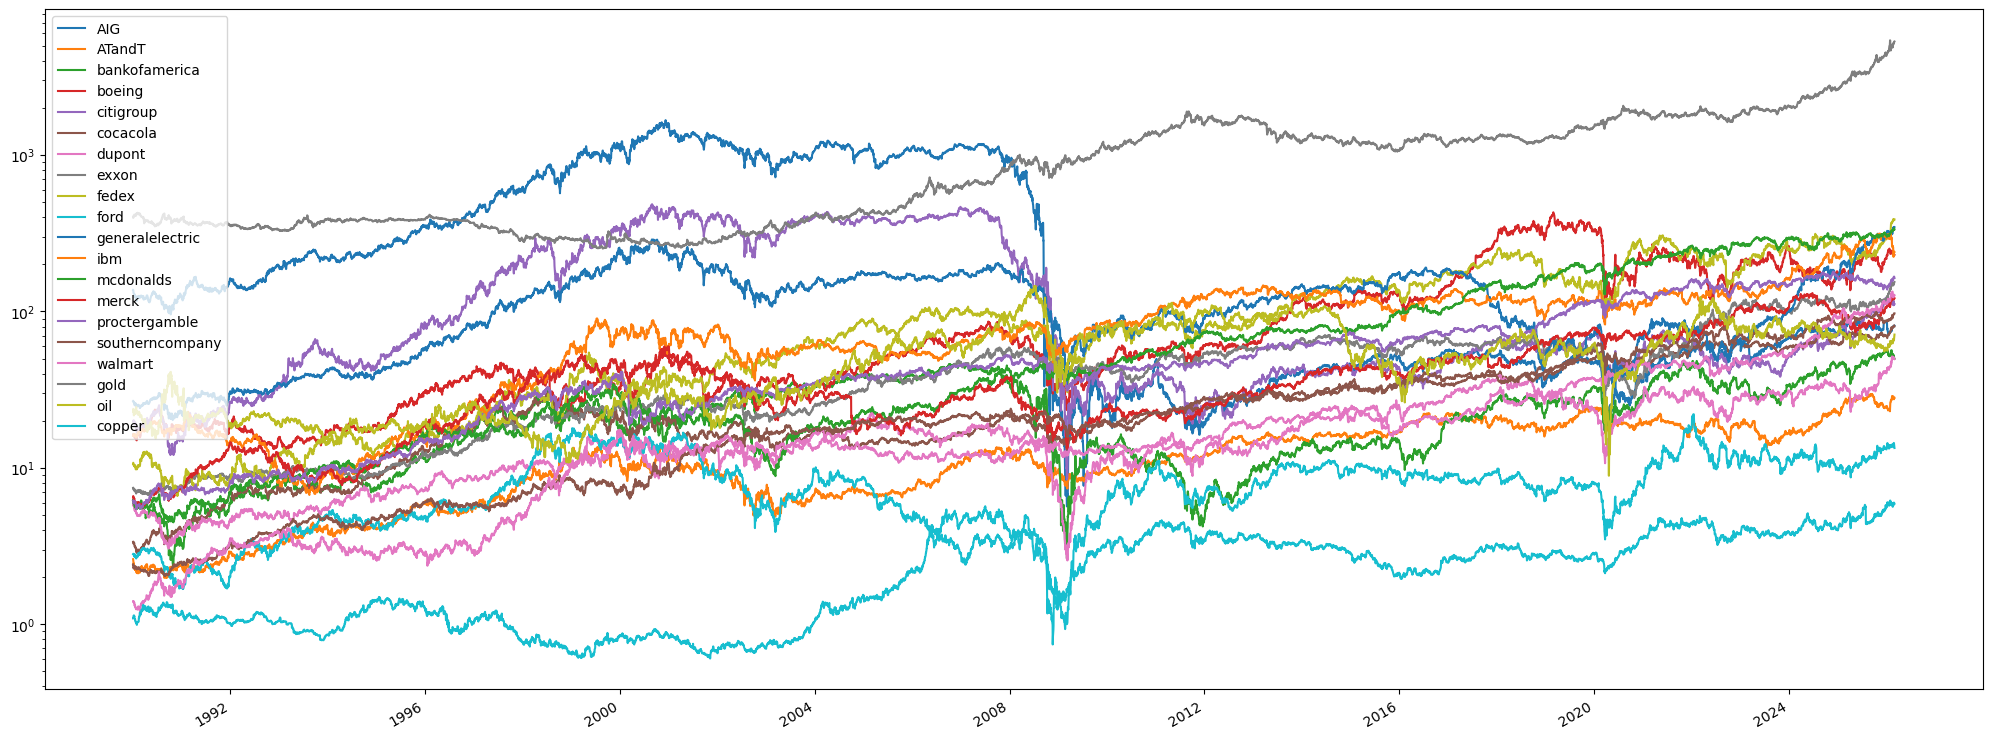

In [5]:
#quick plot of all the assets
prices.plot(figsize=(25,10),logy=True)


#### Calculating the Returns

In [6]:
returns=prices.pct_change()
returns=returns.dropna()
returns

,AIG,ATandT,bankofamerica,boeing,citigroup,cocacola,dupont,exxon,fedex,ford,generalelectric,ibm,mcdonalds,merck,proctergamble,southerncompany,walmart,gold,oil,copper
1990-01-03,-0.001224,-0.017294,0.008101,0.024588,0.012581,-0.014371,0.018050,-0.009924,0.012843,0.004216,-0.001821,0.008822,-0.010452,0.015585,-0.002286,0.004911,0.000000,-0.014176,0.040647,0.000000
1990-01-04,-0.014277,-0.012317,-0.021459,-0.003949,-0.012425,-0.005196,-0.016399,-0.010088,-0.007662,0.000000,-0.005551,0.011575,-0.018636,-0.015346,-0.019429,-0.043844,-0.005407,0.011100,-0.016800,0.025229
1990-01-05,-0.029812,-0.048075,-0.021911,-0.014212,0.008521,-0.008366,-0.004936,-0.005022,-0.025640,-0.012555,-0.009137,-0.002920,-0.017827,-0.020421,-0.017511,-0.017821,-0.010867,0.019212,-0.014524,0.011186
1990-01-08,-0.006156,0.016866,0.005563,0.012560,0.008243,0.022110,-0.005089,0.015289,0.002360,0.000000,0.005656,0.006403,0.018151,0.012888,0.017823,0.028384,0.012804,-0.008568,-0.061985,0.008850
1990-01-09,-0.006110,-0.022140,0.000000,-0.012405,-0.012363,-0.008225,-0.017669,-0.020018,-0.002354,-0.016869,-0.021942,-0.009924,-0.007132,-0.007858,0.000000,-0.009958,-0.025384,0.002963,0.028189,-0.002193
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-02-24,-0.001750,-0.005961,-0.012923,0.012802,-0.010745,0.001986,0.019768,-0.009950,0.007427,0.041056,0.019617,0.026729,-0.004513,0.000888,0.000666,0.006619,0.007472,-0.016005,-0.011151,0.025379
2026-02-25,0.003883,-0.016931,0.025392,-0.012983,0.043629,-0.003097,-0.006462,-0.001340,-0.010270,0.016197,-0.007956,0.035845,-0.000120,-0.011862,-0.011435,0.001148,-0.007890,0.004100,-0.004877,0.011066
2026-02-26,0.002495,-0.014711,0.011801,-0.004124,0.016180,0.000373,-0.007686,-0.003489,0.013304,-0.001386,-0.005979,0.018818,0.004564,-0.025804,0.002203,0.004483,-0.010577,0.003917,-0.003063,-0.002423
2026-02-27,0.001742,0.020029,-0.047228,-0.008195,-0.051640,0.013168,-0.006157,0.026659,-0.001754,-0.022207,0.004166,-0.007438,0.019520,0.037888,0.021069,0.010690,0.028372,0.015153,0.028571,0.001926


#### Splitting the Data into START and BACKTEST

<Axes: >

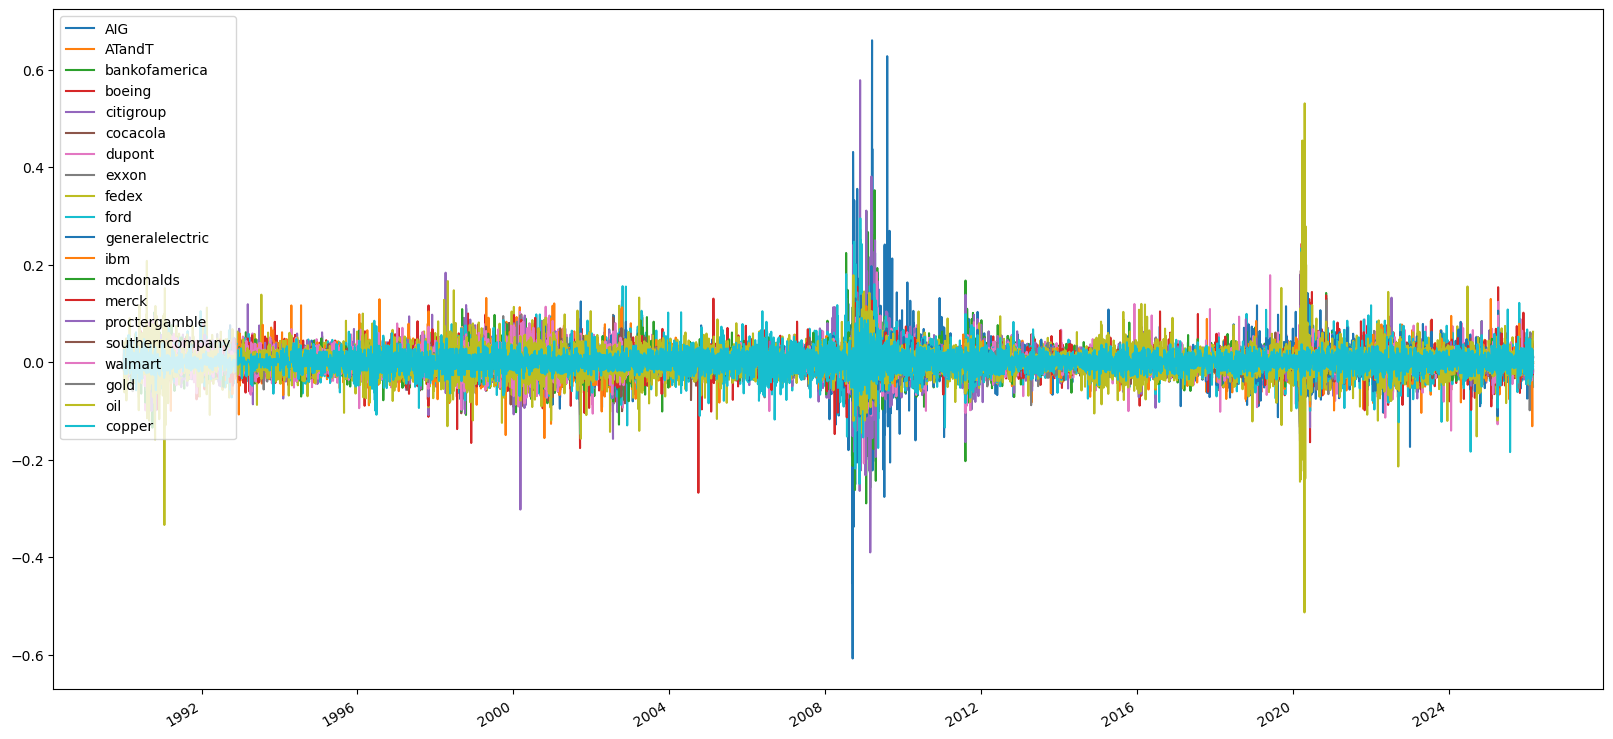

In [7]:
#overal return plots
returns.plot(figsize=(20,10))

In [8]:
#splitting

#Start
returns_start=returns.loc["1990":"12-1999"]

#Backtest
returns_backtest=returns.loc["2000":"2026"]

returns_start

,AIG,ATandT,bankofamerica,boeing,citigroup,cocacola,dupont,exxon,fedex,ford,generalelectric,ibm,mcdonalds,merck,proctergamble,southerncompany,walmart,gold,oil,copper
1990-01-03,-0.001224,-0.017294,0.008101,0.024588,0.012581,-0.014371,0.018050,-0.009924,0.012843,0.004216,-0.001821,0.008822,-0.010452,0.015585,-0.002286,0.004911,0.000000,-0.014176,0.040647,0.000000
1990-01-04,-0.014277,-0.012317,-0.021459,-0.003949,-0.012425,-0.005196,-0.016399,-0.010088,-0.007662,0.000000,-0.005551,0.011575,-0.018636,-0.015346,-0.019429,-0.043844,-0.005407,0.011100,-0.016800,0.025229
1990-01-05,-0.029812,-0.048075,-0.021911,-0.014212,0.008521,-0.008366,-0.004936,-0.005022,-0.025640,-0.012555,-0.009137,-0.002920,-0.017827,-0.020421,-0.017511,-0.017821,-0.010867,0.019212,-0.014524,0.011186
1990-01-08,-0.006156,0.016866,0.005563,0.012560,0.008243,0.022110,-0.005089,0.015289,0.002360,0.000000,0.005656,0.006403,0.018151,0.012888,0.017823,0.028384,0.012804,-0.008568,-0.061985,0.008850
1990-01-09,-0.006110,-0.022140,0.000000,-0.012405,-0.012363,-0.008225,-0.017669,-0.020018,-0.002354,-0.016869,-0.021942,-0.009924,-0.007132,-0.007858,0.000000,-0.009958,-0.025384,0.002963,0.028189,-0.002193
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1999-12-27,-0.020578,-0.036839,-0.007258,0.006198,-0.020054,0.004260,0.038222,-0.021720,0.049866,-0.008223,0.012669,0.010167,0.007722,0.010791,0.015564,-0.007318,0.030594,0.000869,0.019335,0.001792
1999-12-28,-0.005198,0.006279,0.006286,-0.003202,0.018236,-0.006385,0.016829,-0.015830,0.009126,0.005920,-0.014293,0.000639,-0.004680,-0.010676,-0.012843,0.005051,-0.001788,0.006250,0.017071,-0.001789
1999-12-29,0.015143,-0.035759,0.011244,-0.007648,-0.011143,-0.002980,0.027314,0.006199,-0.003142,0.004001,-0.004154,-0.007182,-0.010634,-0.021471,-0.003416,-0.013060,-0.027948,0.003106,-0.014920,0.013142
1999-12-30,0.000000,0.004192,0.016494,0.006258,0.007833,-0.008751,-0.022354,-0.009146,-0.017756,0.012791,-0.009980,-0.002351,-0.009614,-0.006376,0.002344,0.010714,0.006445,-0.008256,-0.024612,0.005307


In [9]:
returns_backtest

,AIG,ATandT,bankofamerica,boeing,citigroup,cocacola,dupont,exxon,fedex,ford,generalelectric,ibm,mcdonalds,merck,proctergamble,southerncompany,walmart,gold,oil,copper
2000-01-04,-0.087862,-0.092026,-0.092097,-0.032447,-0.107047,-0.031109,-0.034437,-0.046395,0.013735,-0.050012,-0.069250,0.039156,-0.037195,-0.029098,-0.040293,-0.021509,-0.069764,-0.020364,-0.007764,-0.017009
2000-01-05,0.002467,0.015247,0.011005,0.063383,0.040783,0.008693,0.032567,0.054243,0.022681,0.003484,-0.002728,0.034490,0.016302,0.040089,-0.019103,0.052279,-0.020462,-0.005418,-0.035603,0.011337
2000-01-06,0.030392,-0.021145,0.085420,0.010433,0.047245,0.001242,0.028102,0.051256,0.113330,0.001401,0.014472,-0.016747,-0.014634,0.007510,0.046379,0.002348,0.010967,0.002136,0.005680,-0.002950
2000-01-07,0.074887,0.008779,-0.026375,0.027837,-0.002949,0.065784,0.022137,-0.003115,0.005291,0.073480,0.039005,-0.004417,0.025999,0.096730,0.079722,0.018432,0.075912,0.001066,0.000000,0.000592
2000-01-10,-0.017666,0.014146,-0.034609,-0.012871,-0.004849,-0.031980,-0.025254,-0.013421,-0.021172,-0.018164,-0.001487,0.039165,0.004758,-0.029717,-0.004811,-0.007802,-0.018342,-0.000532,-0.003227,-0.007096
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-02-24,-0.001750,-0.005961,-0.012923,0.012802,-0.010745,0.001986,0.019768,-0.009950,0.007427,0.041056,0.019617,0.026729,-0.004513,0.000888,0.000666,0.006619,0.007472,-0.016005,-0.011151,0.025379
2026-02-25,0.003883,-0.016931,0.025392,-0.012983,0.043629,-0.003097,-0.006462,-0.001340,-0.010270,0.016197,-0.007956,0.035845,-0.000120,-0.011862,-0.011435,0.001148,-0.007890,0.004100,-0.004877,0.011066
2026-02-26,0.002495,-0.014711,0.011801,-0.004124,0.016180,0.000373,-0.007686,-0.003489,0.013304,-0.001386,-0.005979,0.018818,0.004564,-0.025804,0.002203,0.004483,-0.010577,0.003917,-0.003063,-0.002423
2026-02-27,0.001742,0.020029,-0.047228,-0.008195,-0.051640,0.013168,-0.006157,0.026659,-0.001754,-0.022207,0.004166,-0.007438,0.019520,0.037888,0.021069,0.010690,0.028372,0.015153,0.028571,0.001926


## Covariance Matrix for Start period 1990-1999

In [10]:
returns_start.cov()

,AIG,ATandT,bankofamerica,boeing,citigroup,cocacola,dupont,exxon,fedex,ford,generalelectric,ibm,mcdonalds,merck,proctergamble,southerncompany,walmart,gold,oil,copper
AIG,0.000242,7.217542e-05,0.000137,0.000079,0.000155,0.000087,0.000063,0.000047,0.000090,0.000087,1.040844e-04,0.000070,0.000077,0.000084,0.000077,0.000042,0.000108,-0.000011,-0.000039,2.618728e-06
ATandT,0.000072,2.376470e-04,0.000074,0.000053,0.000087,0.000075,0.000039,0.000050,0.000057,0.000061,7.342556e-05,0.000046,0.000064,0.000062,0.000070,0.000060,0.000077,-0.000006,-0.000030,-7.401911e-07
bankofamerica,0.000137,7.358150e-05,0.000386,0.000088,0.000213,0.000097,0.000084,0.000045,0.000106,0.000113,1.144157e-04,0.000086,0.000079,0.000092,0.000083,0.000044,0.000118,-0.000020,-0.000048,-1.815207e-06
boeing,0.000079,5.289515e-05,0.000088,0.000330,0.000111,0.000080,0.000073,0.000047,0.000069,0.000075,8.673839e-05,0.000069,0.000061,0.000076,0.000066,0.000030,0.000086,-0.000014,-0.000044,6.258171e-06
citigroup,0.000155,8.660525e-05,0.000213,0.000111,0.000484,0.000116,0.000095,0.000064,0.000130,0.000135,1.367534e-04,0.000115,0.000102,0.000117,0.000110,0.000053,0.000141,-0.000007,-0.000029,-4.037424e-06
cocacola,0.000087,7.502990e-05,0.000097,0.000080,0.000116,0.000240,0.000064,0.000060,0.000075,0.000072,1.029500e-04,0.000055,0.000089,0.000104,0.000109,0.000050,0.000106,-0.000015,-0.000043,3.630172e-06
dupont,0.000063,3.948456e-05,0.000084,0.000073,0.000095,0.000064,0.000232,0.000035,0.000073,0.000074,6.759144e-05,0.000043,0.000048,0.000054,0.000050,0.000024,0.000069,-0.000009,-0.000035,9.258902e-06
exxon,0.000047,5.022312e-05,0.000045,0.000047,0.000064,0.000060,0.000035,0.000167,0.000040,0.000044,5.427542e-05,0.000037,0.000039,0.000043,0.000050,0.000036,0.000055,-0.000002,0.000039,7.901410e-06
fedex,0.000090,5.735104e-05,0.000106,0.000069,0.000130,0.000075,0.000073,0.000040,0.000438,0.000094,9.388693e-05,0.000077,0.000071,0.000067,0.000071,0.000029,0.000109,-0.000013,-0.000041,7.054999e-06
ford,0.000087,6.066590e-05,0.000113,0.000075,0.000135,0.000072,0.000074,0.000044,0.000094,0.000343,9.429645e-05,0.000078,0.000072,0.000073,0.000064,0.000032,0.000104,-0.000011,-0.000025,7.598652e-06


### To have a better view of the correlation of the assets (in the period 1990-1999) we can compute the correlation matrix and plot it

In [17]:
corr = returns_start.corr()

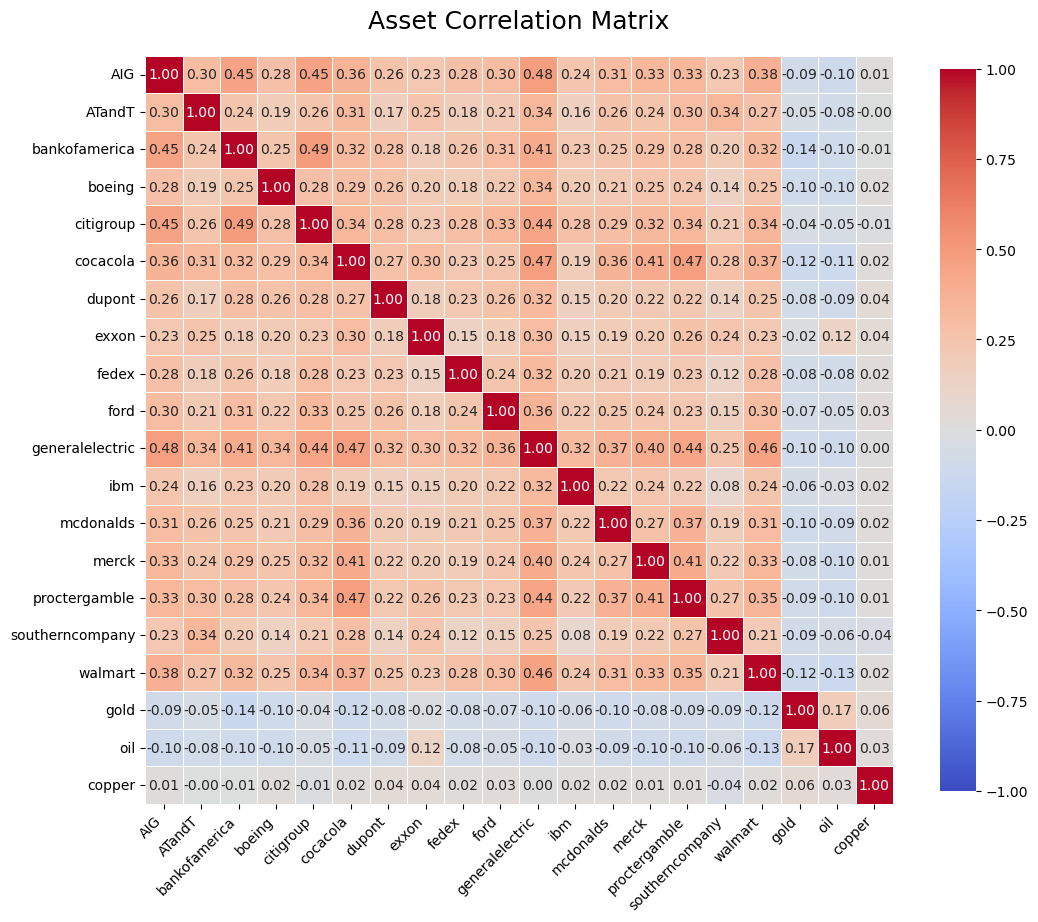

In [18]:
plt.figure(figsize=(11,10))

sns.heatmap(corr,cmap="coolwarm",center=0,vmin=-1,vmax=1,annot=True,fmt=".2f",linewidths=0.5,square=True,cbar_kws={"shrink": .8})
plt.title("Asset Correlation Matrix", fontsize=18, pad=20)
plt.xticks(rotation=45, ha="right", fontsize=10)
plt.yticks(rotation=0, fontsize=10)

plt.tight_layout()
plt.show()

## Is this portfolio really diverified? (1990-1999)
#### Let's check

### Effective number of bets (Eigen Values)

In [26]:
eigvals = np.linalg.eigvals(corr)
ENB = (eigvals.sum()**2) / (eigvals**2).sum()
print("Effective Number of Bets:", ENB)

Effective Number of Bets: 9.360861064755003


**The result is ENB 9.36** despite having 20 assets, which is not that bad and signals a good diversification (expected because we constructed it choosing 1 asset from each sector/industry)

### Cumulative Variance of 80% of Portfolio

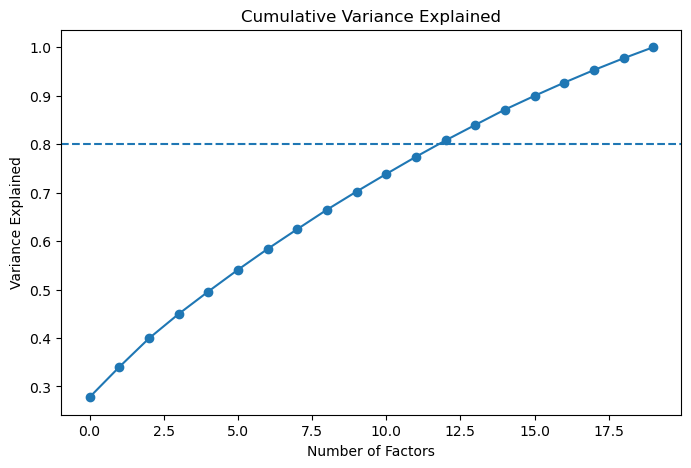

In [24]:
var_explained = eigvals / eigvals.sum()
cum_var = np.cumsum(var_explained)

plt.figure(figsize=(8,5))
plt.plot(cum_var, marker="o")
plt.axhline(0.8, linestyle="--")
plt.title("Cumulative Variance Explained")
plt.xlabel("Number of Factors")
plt.ylabel("Variance Explained")
plt.show()

The cumulative variance plot shows how many independent risk factors are needed to explain the portfolio structure. 
**Around 12 factors are required to explain approximately 80% of the total variance**, indicating that although the universe contains 20 assets, the effective dimensionality of risk is significantly lower due to correlations between assets.

### Variance by Factor

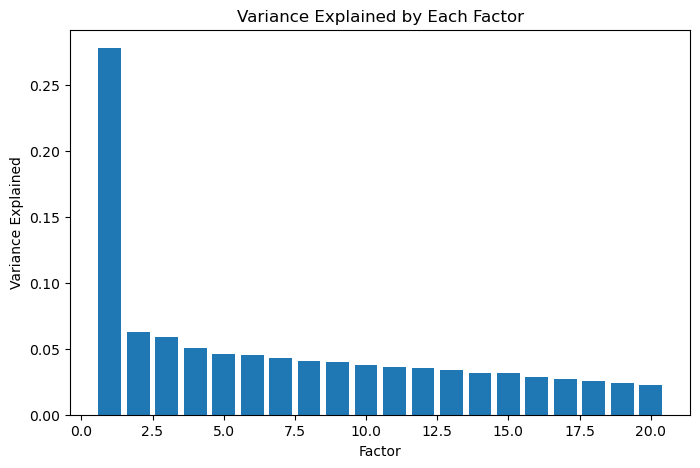

In [25]:
plt.figure(figsize=(8,5))
plt.bar(range(1,len(var_explained)+1), var_explained)
plt.title("Variance Explained by Each Factor")
plt.xlabel("Factor")
plt.ylabel("Variance Explained")
plt.show()

The variance explained by each factor highlights the dominance of the first principal component, which captures the common market movement shared by many equities.  
Subsequent factors contribute progressively smaller portions of variance, representing sector differences, commodity dynamics, and other secondary sources of risk in the portfolio.

## Starting Risk Parity Portfolio